**1. Regresión Logística**
---
Propiedad de René Adarme Amado
---
Universidad Antonio Nariño - Tesis de Maestría en Hidrogeología Ambiental
Abril de 2025

# **Librerías**

In [70]:
# 1. Librerías requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, accuracy_score, RocCurveDisplay, precision_score, recall_score,
    f1_score, make_scorer
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# **Preprocesado**

In [71]:
# 2. Cargar y limpiar la base
base = pd.read_excel("Base_2025_v3.xlsx")
base.drop(columns=['ID', 'Tipo_Estructuras', 'Alturas'], inplace=True)

variables_numericas = base.select_dtypes(include=['float64', 'int64']).columns.tolist()
variables_numericas.remove('Agua')
variables_categoricas = base.select_dtypes(include=['object']).columns.tolist()

X = base.drop(columns=['Agua'])
y = base['Agua'].astype(int)

# 3. Preprocesador
despacho = ColumnTransformer([
    ('numericas', StandardScaler(), variables_numericas),
    ('categoricas', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), variables_categoricas)
])


#**MODELO 1**

# **Encontrar k óptimo**

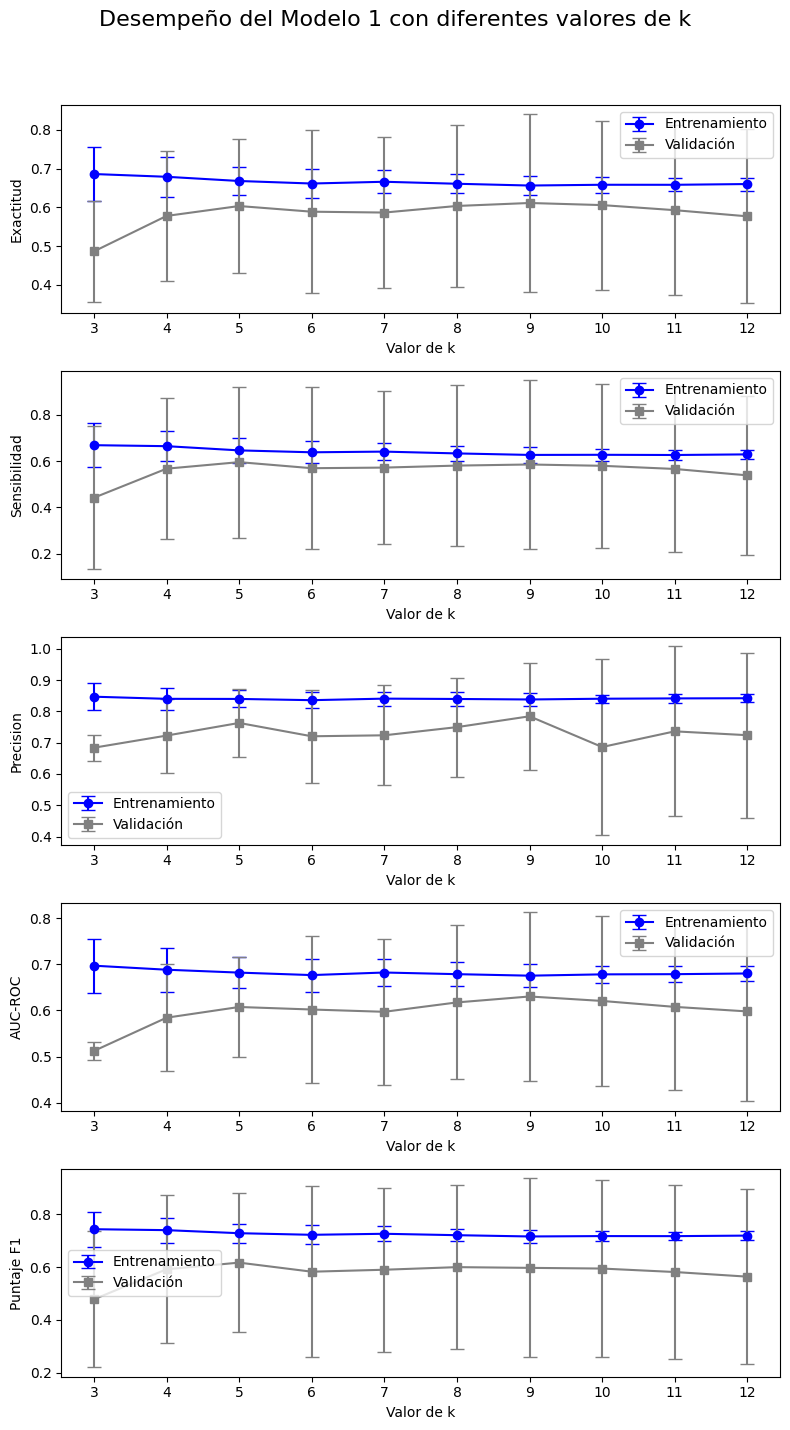

Resumen por valor de k para Precisión y Sensibilidad (validación):
k    Métrica        Media     Desviación
3    Precision      0.6839   0.0416
3    Sensibilidad   0.4420   0.3082
4    Precision      0.7225   0.1180
4    Sensibilidad   0.5670   0.3050
5    Precision      0.7630   0.1079
5    Sensibilidad   0.5952   0.3256
6    Precision      0.7204   0.1487
6    Sensibilidad   0.5691   0.3482
7    Precision      0.7235   0.1596
7    Sensibilidad   0.5717   0.3287
8    Precision      0.7495   0.1583
8    Sensibilidad   0.5803   0.3468
9    Precision      0.7842   0.1717
9    Sensibilidad   0.5851   0.3620
10   Precision      0.6861   0.2818
10   Sensibilidad   0.5794   0.3528
11   Precision      0.7361   0.2711
11   Sensibilidad   0.5659   0.3557
12   Precision      0.7238   0.2635
12   Sensibilidad   0.5383   0.3421


In [72]:
# 4. Definir el modelo base (modelo1)
modelo1 = ImbPipeline([
    ('preprocesador', despacho),
    ('smote', SMOTE(random_state=123)),
    ('clasificador', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=123
    ))
])

# 5. Validacion cruzada exploratoria para k
valores_k = list(range(3, 13))
metricas = {
    'Exactitud': make_scorer(accuracy_score),
    'Sensibilidad': make_scorer(recall_score),
    'Precision': 'precision',
    'AUC-ROC': make_scorer(roc_auc_score),
    'Puntaje F1': 'f1'
}

resultados_por_k = {}
for k in valores_k:
    resultados_cv = cross_validate(modelo1, X, y, cv=k, scoring=metricas, return_train_score=True)
    resultados_por_k[k] = {
        metrica: {
            'media_entrenamiento': np.mean(resultados_cv['train_' + metrica]),
            'desviacion_entrenamiento': np.std(resultados_cv['train_' + metrica]),
            'media_validacion': np.mean(resultados_cv['test_' + metrica]),
            'desviacion_validacion': np.std(resultados_cv['test_' + metrica])
        } for metrica in metricas
    }

# 6. Gráficar métricas para cada valor de k
fig, axes = plt.subplots(len(metricas), 1, figsize=(8, 15))
fig.suptitle('Desempeño del Modelo 1 con diferentes valores de k', fontsize=16)

for i, metrica in enumerate(metricas):
    medias_entrenamiento = [resultados_por_k[k][metrica]['media_entrenamiento'] for k in valores_k]
    desviaciones_entrenamiento = [resultados_por_k[k][metrica]['desviacion_entrenamiento'] for k in valores_k]
    medias_validacion = [resultados_por_k[k][metrica]['media_validacion'] for k in valores_k]
    desviaciones_validacion = [resultados_por_k[k][metrica]['desviacion_validacion'] for k in valores_k]

    axes[i].errorbar(valores_k, medias_entrenamiento, yerr=desviaciones_entrenamiento, marker='o', capsize=5, label='Entrenamiento', color='blue')
    axes[i].errorbar(valores_k, medias_validacion, yerr=desviaciones_validacion, marker='s', capsize=5, label='Validación', color='grey')
    axes[i].set_ylabel(metrica)
    axes[i].set_xlabel('Valor de k')
    axes[i].set_xticks(valores_k)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Mostrar Tabla de Precision y Sensibilidad por cada k
print("Resumen por valor de k para Precisión y Sensibilidad (validación):")
print(f"{'k':<5}{'Métrica':<15}{'Media':<10}{'Desviación'}")
for k in valores_k:
    for metrica in ['Precision', 'Sensibilidad']:
        media = resultados_por_k[k][metrica]['media_validacion']
        std = resultados_por_k[k][metrica]['desviacion_validacion']
        print(f"{k:<5}{metrica:<15}{media:.4f}   {std:.4f}")

In [73]:
# 7. Seleccionar el K óptimo (Criterios: altos valores de Precisión y sensibildad y menor desviación estándar)

# Estructurar un DataFrame con los resultados
resultados_lista = []

for k in valores_k:
    exactitud_media = resultados_por_k[k]['Precision']['media_validacion']
    exactitud_std = resultados_por_k[k]['Precision']['desviacion_validacion']
    sensibilidad_media = resultados_por_k[k]['Sensibilidad']['media_validacion']
    sensibilidad_std = resultados_por_k[k]['Sensibilidad']['desviacion_validacion']

    resultados_lista.append({
        'k': k,
        'Precision_media': exactitud_media,
        'Precision_std': exactitud_std,
        'Sensibilidad_media': sensibilidad_media,
        'Sensibilidad_std': sensibilidad_std
    })

# Generar un DataFrame con los resultados
df_resultados = pd.DataFrame(resultados_lista)

# Ordenar por Precision (descendente) y luego por desviación de Precisión (ascendente)
df_resultados_sorted_exactitud = df_resultados.sort_values(by=['Precision_media', 'Precision_std'], ascending=[False, True])

# Ordenar por Sensibilidad (descendente) y luego por desviación de Sensibilidad (ascendente)
df_resultados_sorted_sensibilidad = df_resultados_sorted_exactitud.sort_values(by=['Sensibilidad_media', 'Sensibilidad_std'], ascending=[False, True])

# Mostrar los tres mejores resultados
top3 = df_resultados_sorted_sensibilidad.head(1)
print("Los tres mejores valores de k según los criterios de Exactitud y Sensibilidad son:\n")
print(top3[['k', 'Precision_media', 'Precision_std', 'Sensibilidad_media', 'Sensibilidad_std']])


Los tres mejores valores de k según los criterios de Exactitud y Sensibilidad son:

   k  Precision_media  Precision_std  Sensibilidad_media  Sensibilidad_std
2  5         0.762956       0.107933            0.595228          0.325627


# **Modelar con k óptimo**

In [74]:
# 8. Entrenar el Modelo 1 con el k óptimo
k_optimo = 5
resultados_final_m1 = cross_validate(modelo1, X, y, cv=k_optimo, scoring=metricas, return_train_score=True) # Contiene las métricas por cada K

# Inspeccionar las claves del diccionario resultados_final_m1
print(resultados_final_m1.keys())

# Mostrar medias y desviaciones para Precision y Sensibilidad en entrenamiento y validación
met_evaluar = {
    'Precision': 'Precision',
    'Sensibilidad': 'Sensibilidad',
    'Puntaje F1': 'Puntaje F1',
    'AUC-ROC': 'AUC-ROC'
}

print("\nResumen de métricas del Modelo 1 (k = 5):\n")
print(f"{'Métrica':<15}{'Conjunto':<15}{'Media':<10}{'Desviación'}")
for nombre_metrica, clave in met_evaluar.items():
    media_train = np.mean(resultados_final_m1[f'train_{clave}'])
    std_train = np.std(resultados_final_m1[f'train_{clave}'])
    media_val = np.mean(resultados_final_m1[f'test_{clave}'])
    std_val = np.std(resultados_final_m1[f'test_{clave}'])
    print(f"{nombre_metrica:<15}{'Entrenamiento':<15}{media_train:.4f}   {std_train:.4f}")
    print(f"{nombre_metrica:<15}{'Validación':<15}{media_val:.4f}   {std_val:.4f}")

dict_keys(['fit_time', 'score_time', 'test_Exactitud', 'train_Exactitud', 'test_Sensibilidad', 'train_Sensibilidad', 'test_Precision', 'train_Precision', 'test_AUC-ROC', 'train_AUC-ROC', 'test_Puntaje F1', 'train_Puntaje F1'])

Resumen de métricas del Modelo 1 (k = 5):

Métrica        Conjunto       Media     Desviación
Precision      Entrenamiento  0.8396   0.0273
Precision      Validación     0.7630   0.1079
Sensibilidad   Entrenamiento  0.6458   0.0543
Sensibilidad   Validación     0.5952   0.3256
Puntaje F1     Entrenamiento  0.7287   0.0366
Puntaje F1     Validación     0.6171   0.2639
AUC-ROC        Entrenamiento  0.6820   0.0340
AUC-ROC        Validación     0.6075   0.1091


#**MODELO 2**

# **Encontrar hiperparámetros**

In [75]:
# 9. Definir el Modelo 2
modelo2 = ImbPipeline([
    ('preprocesador', despacho),
    ('smote', SMOTE(random_state=123)),
    ('clasificador', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=123))
])

# Definir el espacio de hiperparámetros para el GridSearch
param_grid = [
    {'clasificador__penalty': ['l1'], 'clasificador__C': [0.001, 0.01, 0.1, 1, 10], 'clasificador__solver': ['liblinear', 'saga']},
    {'clasificador__penalty': ['l2'], 'clasificador__C': [0.001, 0.01, 0.1, 1, 10], 'clasificador__solver': ['lbfgs', 'newton-cg', 'sag', 'saga']},
    {'clasificador__penalty': ['elasticnet'], 'clasificador__C': [0.001, 0.01, 0.1, 1, 10], 'clasificador__l1_ratio': [0.2, 0.5, 0.7], 'clasificador__solver': ['saga']}
]

# Ejecutar GridSearchCV
busqueda = GridSearchCV(modelo2_base, param_grid=param_grid, cv=5, scoring='precision', n_jobs=-1)
busqueda.fit(X, y)

# Obtener los mejores parámetros encontrados
mejores_parametros = {k.replace('clasificador__', ''): v for k, v in busqueda.best_params_.items()}

# Mostrar los mejores parámetros
print("Los mejores hiperparámetros encontrados por GridSearch son:")
print(mejores_parametros)


Los mejores hiperparámetros encontrados por GridSearch son:
{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


# **Modelar con mejores hiperparámetros**

In [76]:
# 10. Entrenar el Modelo 2 con el k óptimo y con los mejores hiperparámetros
k_optimo = 5

modelo2_final = ImbPipeline([
    ('preprocesador', despacho),
    ('smote', SMOTE(random_state=123)),
    ('clasificador', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=123,
        **mejores_parametros  # Desempacar los mejores parámetros aquí
    ))
])

metricas = {
       'precision': make_scorer(precision_score),
       'recall': make_scorer(recall_score),
       'f1': make_scorer(f1_score),
       'roc_auc': make_scorer(roc_auc_score)
   }

# Realizar una validación cruzada con el modelo ajustado
resultados_final_m2 = cross_validate(modelo2_final, X, y, cv=k_optimo, scoring=metricas, return_train_score=True)


# Mostrar resultados de entrenamiento y validación
print("\nResumen de métricas del Modelo 2 (con k=5):\n")
print(f"{'Métrica':<15}{'Conjunto':<15}{'Media':<10}{'Desviación'}")

met_evaluar = {
       'Precision': 'precision',
       'Sensibilidad': 'recall',
       'Puntaje F1': 'f1',
       'AUC-ROC': 'roc_auc'
   }

for nombre_metrica, clave in met_evaluar.items():
       media_train = np.mean(resultados_final_m2[f'train_{clave}'])
       std_train = np.std(resultados_final_m2[f'train_{clave}'])
       media_val = np.mean(resultados_final_m2[f'test_{clave}'])
       std_val = np.std(resultados_final_m2[f'test_{clave}'])
       print(f"{nombre_metrica:<15}{'Entrenamiento':<15}{media_train:.4f}   {std_train:.4f}")
       print(f"{nombre_metrica:<15}{'Validación':<15}{media_val:.4f}   {std_val:.4f}")



Resumen de métricas del Modelo 2 (con k=5):

Métrica        Conjunto       Media     Desviación
Precision      Entrenamiento  0.8377   0.0384
Precision      Validación     0.7846   0.1024
Sensibilidad   Entrenamiento  0.6173   0.0642
Sensibilidad   Validación     0.5982   0.3245
Puntaje F1     Entrenamiento  0.7088   0.0458
Puntaje F1     Validación     0.6266   0.2728
AUC-ROC        Entrenamiento  0.6715   0.0439
AUC-ROC        Validación     0.6300   0.1363


# **Curva ROC**

Solo ilustrativo.

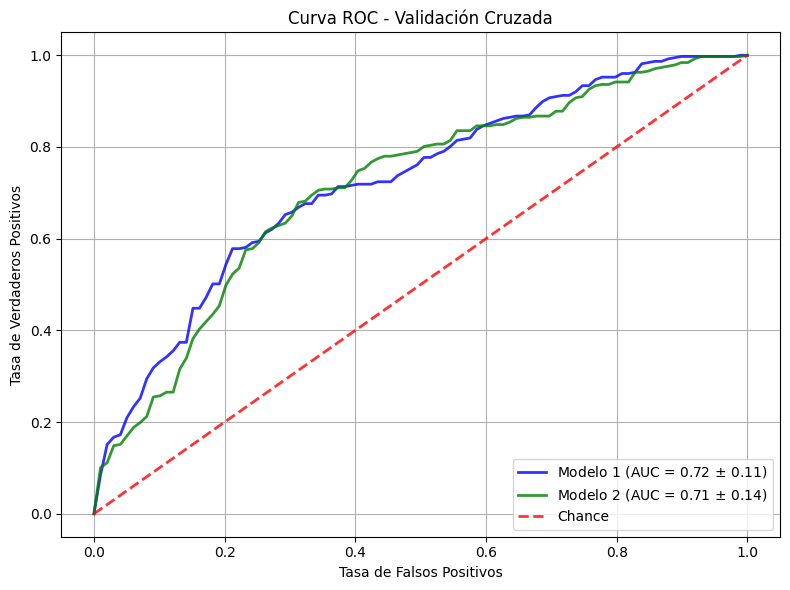

In [77]:
# 11. Curvas ROC utilizando los resultados de la validación cruzada
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Entrenar el Modelo 1 con todo el conjunto de datos
modelo1.fit(X, y)

# Configurar el modelo2_final antes de usarlo
modelo2_final.fit(X, y)

# Predicciones probabilísticas de la validación cruzada para el Modelo 1
probs_m1_val = resultados_final_m1['test_AUC-ROC']

# Predicciones probabilísticas de la validación cruzada para el Modelo 2
probs_m2_val = resultados_final_m2['test_roc_auc']

# Generar las curvas ROC para los modelos 1 y 2
# Promediar las curvas ROC de cada pliegue de la validación cruzada
tprs_m1 = []
aucs_m1 = []
mean_fpr_m1 = np.linspace(0, 1, 100)

tprs_m2 = []
aucs_m2 = []
mean_fpr_m2 = np.linspace(0, 1, 100)

for i in range(k_optimo):
    # Modelo 1
    fpr_m1, tpr_m1, _ = roc_curve(y, modelo1.predict_proba(X)[:, 1])
    interp_tpr_m1 = np.interp(mean_fpr_m1, fpr_m1, tpr_m1)
    interp_tpr_m1[0] = 0.0
    tprs_m1.append(interp_tpr_m1)
    aucs_m1.append(probs_m1_val[i]) # Usar el AUC de la validación cruzada

    # Modelo 2
    fpr_m2, tpr_m2, _ = roc_curve(y, modelo2_final.predict_proba(X)[:, 1])
    interp_tpr_m2 = np.interp(mean_fpr_m2, fpr_m2, tpr_m2)
    interp_tpr_m2[0] = 0.0
    tprs_m2.append(interp_tpr_m2)
    aucs_m2.append(probs_m2_val[i]) # Usar el AUC de la validación cruzada

# Calcular la curva ROC promedio y el AUC promedio para cada modelo
mean_tpr_m1 = np.mean(tprs_m1, axis=0)
mean_tpr_m1[-1] = 1.0
mean_auc_m1 = auc(mean_fpr_m1, mean_tpr_m1)
std_auc_m1 = np.std(aucs_m1)

mean_tpr_m2 = np.mean(tprs_m2, axis=0)
mean_tpr_m2[-1] = 1.0
mean_auc_m2 = auc(mean_fpr_m2, mean_tpr_m2)
std_auc_m2 = np.std(aucs_m2)

# Graficar las curvas ROC promedio
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr_m1, mean_tpr_m1, color='b',
         label=r'Modelo 1 (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_m1, std_auc_m1),
         lw=2, alpha=.8)

plt.plot(mean_fpr_m2, mean_tpr_m2, color='g',
         label=r'Modelo 2 (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_m2, std_auc_m2),
         lw=2, alpha=.8)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

plt.title("Curva ROC - Validación Cruzada")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Las curvas son ilustrativas y los AUC oficiales se calculan en la sección 11 desde la validación cruzada.